In [16]:
import numpy as np
import matplotlib.pyplot as plt

from slmsuite.hardware.slms.simulated import SimulatedSLM
from slmsuite.holography.algorithms import SpotHologram

print("Imports successful!")

Imports successful!


In [17]:
# ============================================================
# SLM PARAMETERS
# ============================================================

SLM_WIDTH = 1920
SLM_HEIGHT = 1200

PIXEL_PITCH_UM = 8.0
WAVELENGTH_UM = 0.759


# ============================================================
# INPUT BEAM
# ============================================================

# 1/e^2 intensity diameter measured on the SLM
BEAM_DIAMETER_UM = 9600.0

# Therefore 1/e^2 intensity radius
BEAM_RADIUS_UM = BEAM_DIAMETER_UM / 2


# ============================================================
# TWEEZER ARRAY
# ============================================================

ARRAY_NX = 10
ARRAY_NY = 10

# For now this is spacing in computational Fourier pixels.
# It is NOT yet 5 um in the atom plane.
ARRAY_PITCH_KNM = 20


# ============================================================
# WGS PARAMETERS
# ============================================================

N_ITERATIONS = 30

In [18]:
slm = SimulatedSLM(
    (SLM_WIDTH, SLM_HEIGHT),
    pitch_um=(PIXEL_PITCH_UM, PIXEL_PITCH_UM),
    wav_um=WAVELENGTH_UM
)

print("Simulated SLM created")
print("---------------------")
print("SLM shape      :", slm.shape)
print("Pixel pitch    :", PIXEL_PITCH_UM, "um")
print("Wavelength     :", WAVELENGTH_UM, "um")
print("Beam diameter  :", BEAM_DIAMETER_UM / 1000, "mm")

Simulated SLM created
---------------------
SLM shape      : (1200, 1920)
Pixel pitch    : 8.0 um
Wavelength     : 0.759 um
Beam diameter  : 9.6 mm


In [19]:
Ny, Nx = slm.shape

# Physical coordinates of SLM pixels
x_um = (np.arange(Nx) - (Nx - 1) / 2) * PIXEL_PITCH_UM
y_um = (np.arange(Ny) - (Ny - 1) / 2) * PIXEL_PITCH_UM

X_um, Y_um = np.meshgrid(x_um, y_um)

r2 = X_um**2 + Y_um**2


# Gaussian FIELD amplitude
#
# A(r) = exp(-r^2 / w^2)
#
# Thus intensity:
#
# I(r) = |A|^2 = exp(-2 r^2 / w^2)

amp = np.exp(-r2 / BEAM_RADIUS_UM**2)

intensity_slm = amp**2

print("Amplitude array shape:", amp.shape)
print("Maximum amplitude     :", amp.max())
print("Minimum amplitude     :", amp.min())

Amplitude array shape: (1200, 1920)
Maximum amplitude     : 0.9999986111120757
Minimum amplitude     : 0.028562287346471392


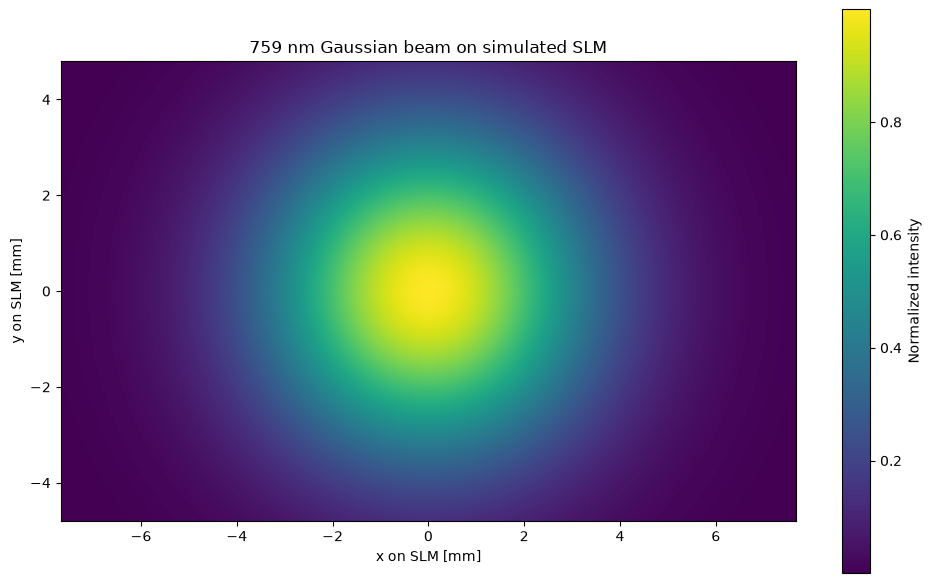

In [20]:
extent_mm = [
    x_um[0] / 1000,
    x_um[-1] / 1000,
    y_um[0] / 1000,
    y_um[-1] / 1000
]

plt.figure(figsize=(10, 6))

plt.imshow(
    intensity_slm,
    origin="lower",
    extent=extent_mm
)

plt.colorbar(label="Normalized intensity")

plt.xlabel("x on SLM [mm]")
plt.ylabel("y on SLM [mm]")

plt.title("759 nm Gaussian beam on simulated SLM")

plt.tight_layout()
plt.show()

In [21]:
holo = SpotHologram.make_rectangular_array(
    slm.shape,

    array_shape=(ARRAY_NX, ARRAY_NY),

    array_pitch=(
        ARRAY_PITCH_KNM,
        ARRAY_PITCH_KNM
    ),

    basis="knm",

    amp=amp,

    slm_shape=slm.shape
)

print("10 x 10 target hologram created!")

10 x 10 target hologram created!


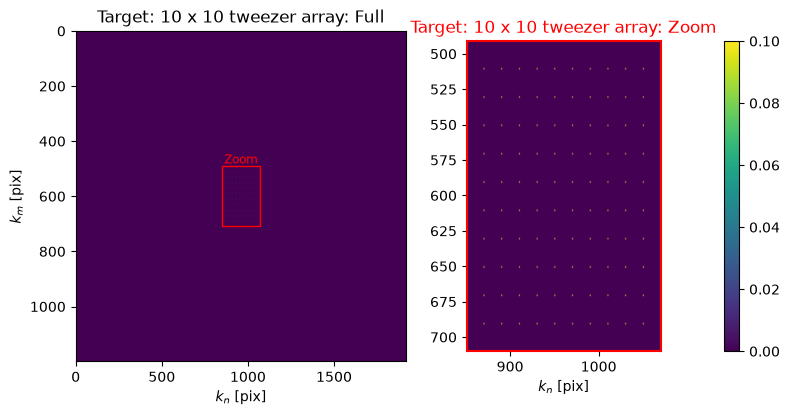

In [22]:
zoom = holo.plot_farfield(
    source=holo.target,
    title="Target: 10 x 10 tweezer array",
    cbar=True
)

plt.show()

In [23]:
print("Starting WGS-Kim optimization...")

holo.optimize(
    method="WGS-Kim",
    maxiter=N_ITERATIONS,
    stat_groups=["computational_spot"],
    verbose=2
)

print("WGS-Kim optimization finished!")

Starting WGS-Kim optimization...
Optimizing with 'WGS-Kim' using the following method-specific flags:
{'feedback': 'computational',
 'feedback_exponent': 0.8,
 'fix_phase_efficiency': None,
 'fix_phase_iteration': 10}


100%|██████████| 30/30 [00:10<00:00,  2.95it/s]

WGS-Kim optimization finished!


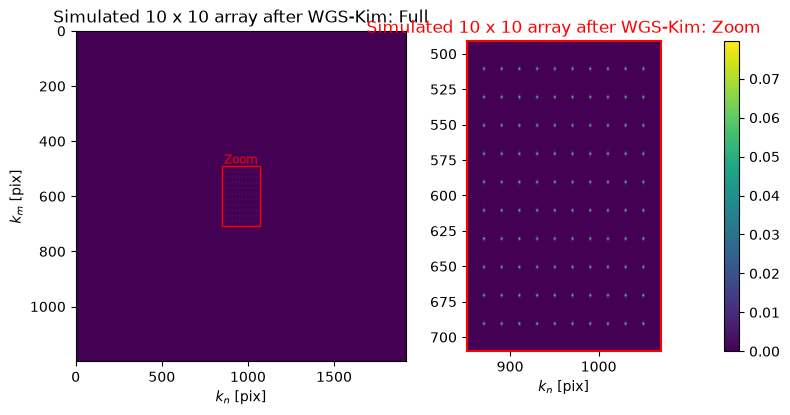

In [24]:
holo.plot_farfield(
    limits=zoom,
    title="Simulated 10 x 10 array after WGS-Kim",
    cbar=True
)

plt.show()

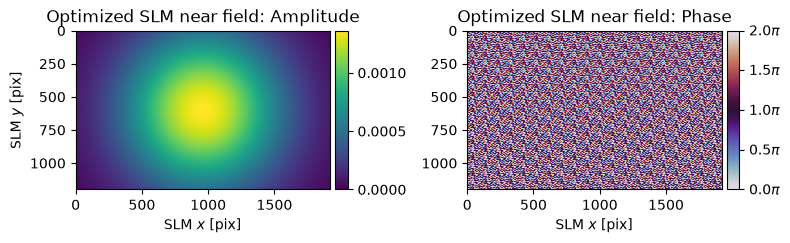

In [25]:
holo.plot_nearfield(
    title="Optimized SLM near field",
    cbar=True
)

plt.show()

In [26]:
phase = holo.get_phase()

print("Phase mask information")
print("----------------------")
print("Shape :", phase.shape)
print("Min   :", phase.min(), "rad")
print("Max   :", phase.max(), "rad")

Phase mask information
----------------------
Shape : (1200, 1920)
Min   : 0.00015616417 rad
Max   : 6.282042 rad


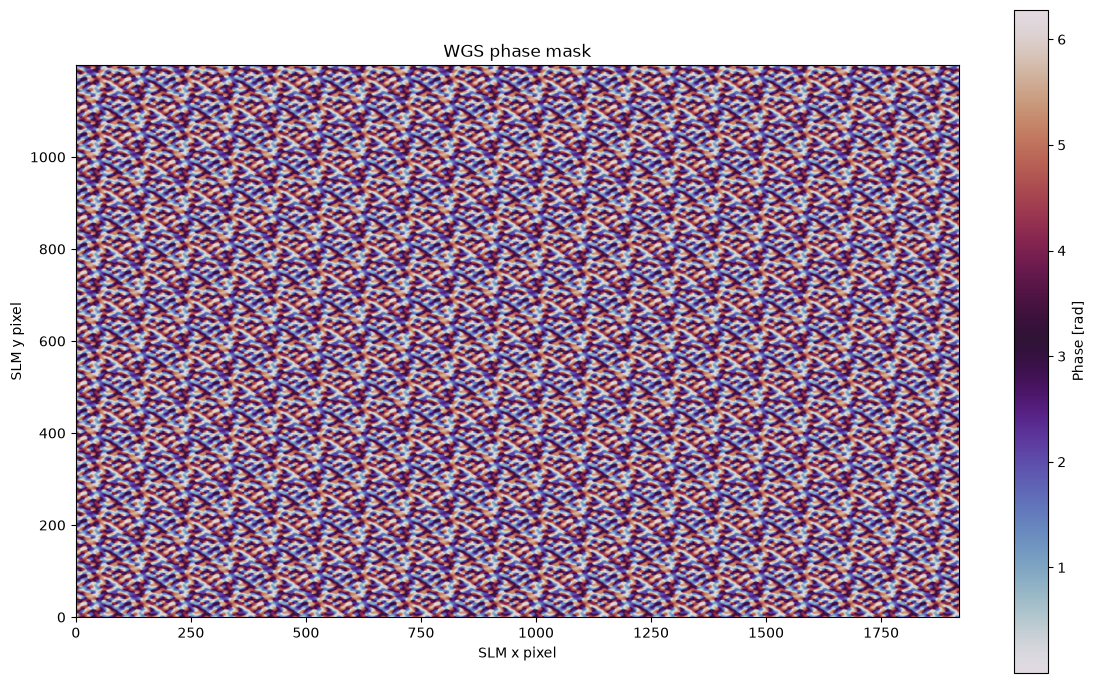

In [27]:
plt.figure(figsize=(12, 7))

plt.imshow(
    phase,
    origin="lower",
    cmap="twilight"
)

plt.colorbar(label="Phase [rad]")

plt.xlabel("SLM x pixel")
plt.ylabel("SLM y pixel")

plt.title("WGS phase mask")

plt.tight_layout()
plt.show()

In [28]:
farfield = holo.get_farfield()

farfield_intensity = np.abs(farfield)**2

# Normalize
farfield_intensity /= farfield_intensity.max()

print("Far-field shape:", farfield_intensity.shape)

Far-field shape: (1200, 1920)


In [29]:
H, W = farfield_intensity.shape

cy = H // 2
cx = W // 2


crop_half_width = int(
    max(ARRAY_NX, ARRAY_NY)
    * ARRAY_PITCH_KNM
    * 0.75
)


crop = farfield_intensity[
    cy - crop_half_width : cy + crop_half_width,
    cx - crop_half_width : cx + crop_half_width
]

print("Crop shape:", crop.shape)

Crop shape: (300, 300)


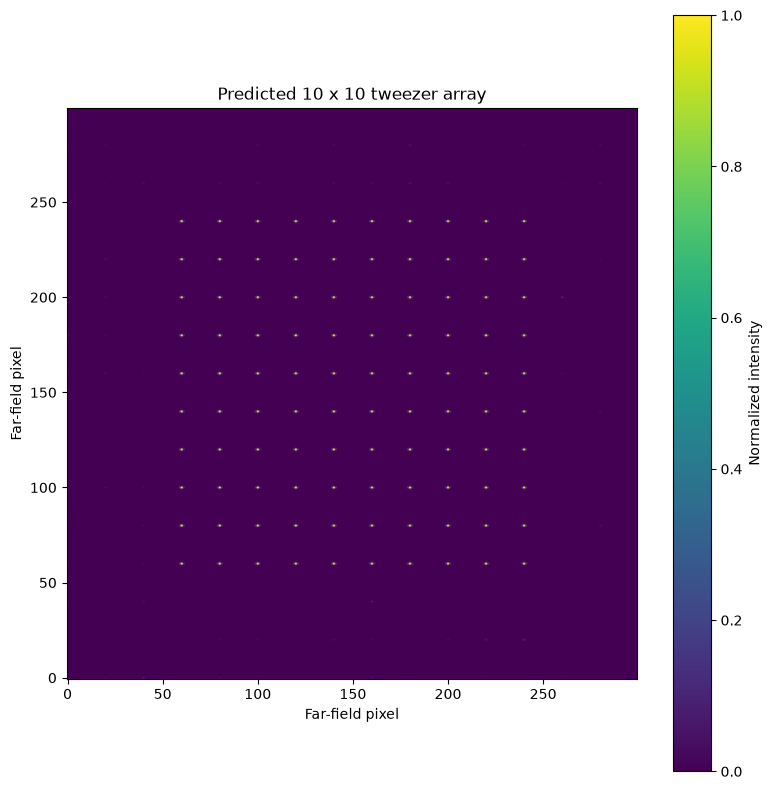

In [30]:
plt.figure(figsize=(8, 8))

plt.imshow(
    crop,
    origin="lower"
)

plt.colorbar(label="Normalized intensity")

plt.xlabel("Far-field pixel")
plt.ylabel("Far-field pixel")

plt.title("Predicted 10 x 10 tweezer array")

plt.tight_layout()
plt.show()

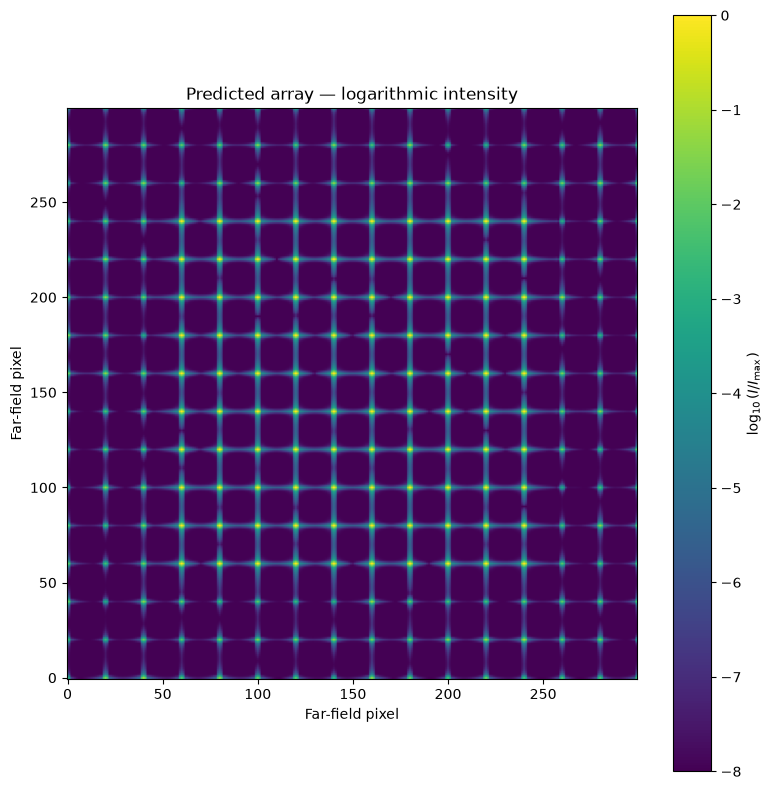

In [31]:
plt.figure(figsize=(8, 8))

plt.imshow(
    np.log10(crop + 1e-8),
    origin="lower"
)

plt.colorbar(label=r"$\log_{10}(I/I_{\max})$")

plt.xlabel("Far-field pixel")
plt.ylabel("Far-field pixel")

plt.title("Predicted array — logarithmic intensity")

plt.tight_layout()
plt.show()

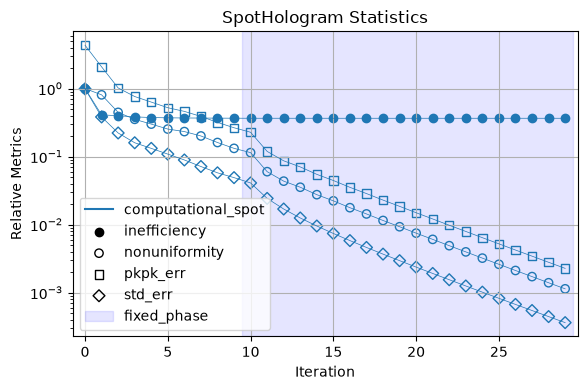

In [32]:
holo.plot_stats()

plt.show()

In [33]:
# Yb 3P1 -> 3D1 wavelength from NIST level energies

E_3P1 = 17992.007   # cm^-1
E_3D1 = 24489.102   # cm^-1

delta_E = E_3D1 - E_3P1       # transition wavenumber in cm^-1
wavelength_nm = 1e7 / delta_E # convert cm^-1 -> nm

print(f"Wavenumber = {delta_E:.3f} cm^-1")
print(f"Wavelength = {wavelength_nm:.4f} nm")

Wavenumber = 6497.095 cm^-1
Wavelength = 1539.1494 nm


In [34]:
# Laser tuning range around 1539.15 nm

c = 299792458          # speed of light [m/s]

lambda0_nm = 1539.15   # central wavelength [nm]
tuning_nm = 0.5        # +/- tuning range [nm]

# Wavelength limits
lambda_min_nm = lambda0_nm - tuning_nm
lambda_max_nm = lambda0_nm + tuning_nm

# Convert wavelength -> frequency
def freq_THz(lambda_nm):
    return c / (lambda_nm * 1e-9) / 1e12

f0 = freq_THz(lambda0_nm)
f_max = freq_THz(lambda_min_nm)   # shorter wavelength = higher frequency
f_min = freq_THz(lambda_max_nm)   # longer wavelength = lower frequency

print(f"Central frequency : {f0:.6f} THz")
print(f"Wavelength range  : {lambda_min_nm:.2f} - {lambda_max_nm:.2f} nm")

print(f"\nDetuning towards shorter λ: +{(f_max-f0)*1000:.2f} GHz")
print(f"Detuning towards longer  λ: {(f_min-f0)*1000:.2f} GHz")

print(f"Total frequency range: {(f_max-f_min)*1000:.2f} GHz")

Central frequency : 194.777935 THz
Wavelength range  : 1538.65 - 1539.65 nm

Detuning towards shorter λ: +63.30 GHz
Detuning towards longer  λ: -63.25 GHz
Total frequency range: 126.55 GHz
